## Figure 2: Preliminary Integrative Analysis

### R Setup
To avoid reimplementing Python-based data import functions in R (and to ensure equivalent results across languages), we use the Python-based data import functions and convert the DataFrames to R.

In [35]:
# Load R magic for Jupyter cells
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [36]:
# Add Python repository to path
import sys
sys.path.append("../../src/python")

In [37]:
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from pilot.data_import import import_global, import_meta, import_phospho, import_rna

In [38]:
meta = import_meta()

# Load in datasets using Python-based functions and concatenate BeatAML 210
# and Pilot cohorts
global_prot = import_global(pre_corrected=False)
global_prot = pd.concat(global_prot, axis=0)
phospho = import_phospho(pre_corrected=False)
phospho = pd.concat(phospho, axis=0)
phospho.columns = phospho.columns.str.replace("-", ".")

rna = import_rna(return_symbols=True, batch_correct=True, tpm=False)
rna = pd.concat(rna, axis=0)
rna = rna.loc[rna.index.intersection(meta.index), :]

# Convert Python objects to R for use in later notebook cells
with localconverter(ro.default_converter + pandas2ri.converter):
    global_r = ro.conversion.py2rpy(global_prot)
    phospho_r = ro.conversion.py2rpy(phospho)
    rna_r = ro.conversion.py2rpy(rna)
    meta_r = ro.conversion.py2rpy(meta)

Welcome, JLChin!

[syn69692583:combinedBeatAML_pilotMetadata.csv]: Found existing file at /Users/jackson.chin/.synapseCache/59/164972059/combinedBeatAML_pilotMetadata.csv, skipping download.
Welcome, JLChin!

[syn25807733:Ex10_metadata.txt]: Found existing file at /Users/jackson.chin/.synapseCache/668/78060668/Ex10_metadata.txt, skipping download.
[syn68835814:PTRC_Exp26 Sample Key.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/432/161070432/PTRC_Exp26 Sample Key.xlsx, skipping download.
Welcome, JLChin!

[syn25807733:Ex10_metadata.txt]: Found existing file at /Users/jackson.chin/.synapseCache/668/78060668/Ex10_metadata.txt, skipping download.
[syn68835814:PTRC_Exp26 Sample Key.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/432/161070432/PTRC_Exp26 Sample Key.xlsx, skipping download.
Welcome, JLChin!

[syn64126462:beataml_waves1to4_counts_dbgap.txt]: Found existing file at /Users/jackson.chin/.synapseCache/867/150013867/beataml_waves1to4_counts_dbgap.t

### Subfigure 2a: Kinase Enrichment Analysis
With the phosphoproteomic measurements, a major question is if differential expression across phosphosites reflects differences in upstream kinase activity. Such kinase behavior may be inferred from phosphoproteomic measurements via Kinase-Substrate Enrichment Analysis (KSEA).

here() starts at /Users/jackson.chin/amlMultidrugResistance/aml_outcome_disparities
In addition: Warning message:
Partial NA coefficients for 17421 probe(s) 


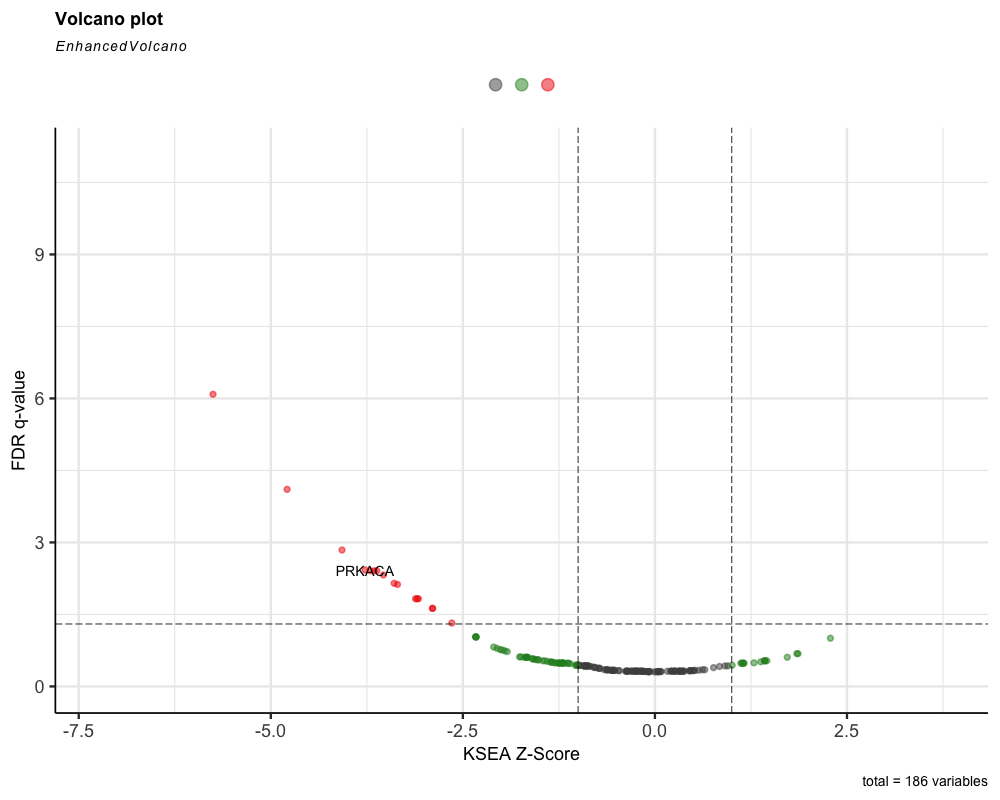

In [39]:
%%R -w 1000 -h 800 -u px -i phospho_r -i meta_r
source("../../src/r/proteomics/run_ksea.R")
ksea_res <- run_ksea(phospho_r, meta_r)
ksea_table <- ksea_res$table
write.csv(ksea_res$table, "ksea_results.csv", row.names = FALSE)
write.csv(ksea_res$links, "Kinase-Substrate Links.csv", row.names = FALSE)
ksea_res$volcano

### Subfigure 2b: PRKACA Substrate Differential Expression
KSEA indicates that PRKACA is exhibiting reduced activity in Black AML patients. To validate, we can examine the differential expression of PRKACA substrates across Black and White patients and use MANOVA to compare mean expression across PRKACA substrates between Black and White patients.

Note that individual t-tests find none of these substrates are significantly differentially expressed across Black and White patients (when accounting for false discovery rate). Strong association via MANOVA, therefore, may indicate that the difference truly is at the kinase level.

Welcome, JLChin!

[syn25807733:Ex10_metadata.txt]: Found existing file at /Users/jackson.chin/.synapseCache/668/78060668/Ex10_metadata.txt, skipping download.
[syn68835814:PTRC_Exp26 Sample Key.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/432/161070432/PTRC_Exp26 Sample Key.xlsx, skipping download.
[syn69692583:combinedBeatAML_pilotMetadata.csv]: Found existing file at /Users/jackson.chin/.synapseCache/59/164972059/combinedBeatAML_pilotMetadata.csv, skipping download.


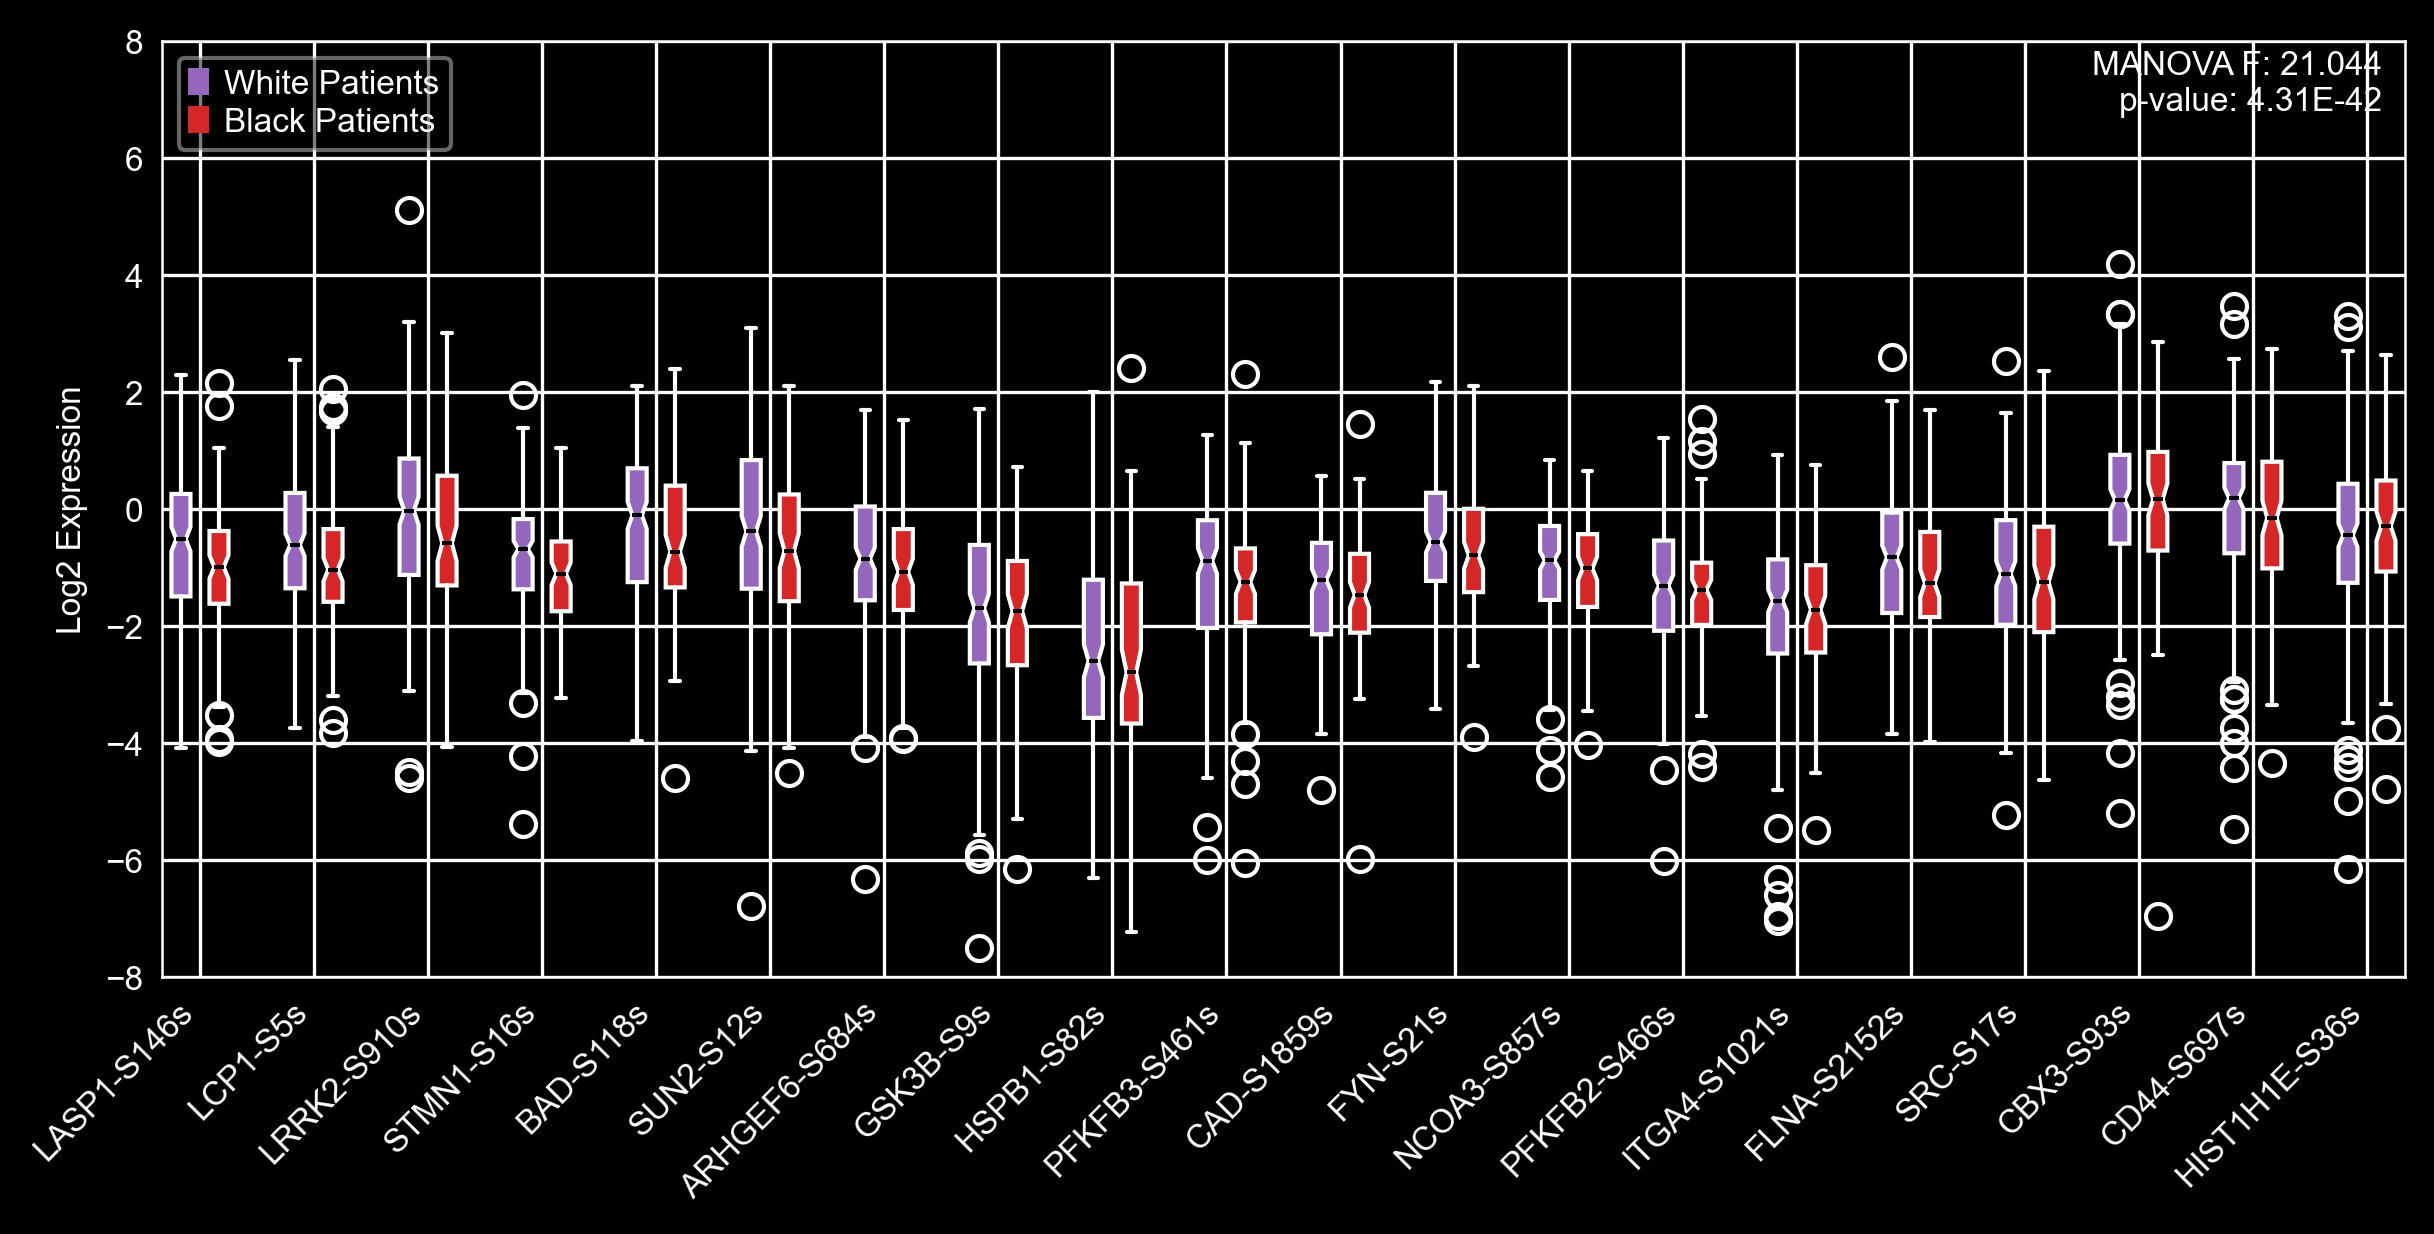

In [40]:
from figure2b import make_figure as make_figure_2b
fig_2b = make_figure_2b()

### Subfigure 2c: PRKACA Substrates & AML Subtypes
MANOVA provides further evidence that PRKACA substrates, and therefore PRKACA activity, are reduced in Black AML patients. To evaluate if these changes in phosphoproteomic expression associate with variation in AML manifestation, we examine the relationship between PRKACA substrate expression and (1) AML cell type scores derived via the scoring approach defined in [Bottomly et al](https://doi.org/10.1016/j.ccell.2022.07.002) and (2) Hematopoietic Aging Scores (HAS) from [Cheng et al](https://doi.org/10.1182/blood.2024027692).

An interesting aside is that the KSEA, cell type scores, and HAS all use different types of data (phosphoproteomic, transcriptomic, and global proteomic, respectively), indicating both that (1) integration of modalities provides a more comprehensive understanding of the underlying immunology and (2) that these conclusions are somewhat further reinforced as they are supported by multiple types of data.

Welcome, JLChin!

[syn25807733:Ex10_metadata.txt]: Found existing file at /Users/jackson.chin/.synapseCache/668/78060668/Ex10_metadata.txt, skipping download.
[syn68835814:PTRC_Exp26 Sample Key.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/432/161070432/PTRC_Exp26 Sample Key.xlsx, skipping download.
[syn64126462:beataml_waves1to4_counts_dbgap.txt]: Found existing file at /Users/jackson.chin/.synapseCache/867/150013867/beataml_waves1to4_counts_dbgap.txt, skipping download.
[syn68820229:RNAseq expression data.txt]: Found existing file at /Users/jackson.chin/.synapseCache/317/160991317/RNAseq expression data.txt, skipping download.
[syn68820228:PilotYR_1_2_metadata_083024_withRNA DN.csv]: Found existing file at /Users/jackson.chin/.synapseCache/316/160991316/PilotYR_1_2_metadata_083024_withRNA DN.csv, skipping download.
[syn64126463:beataml_waves1to4_sample_mapping.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/872/150013872/beataml_waves1to4_sample_mapp

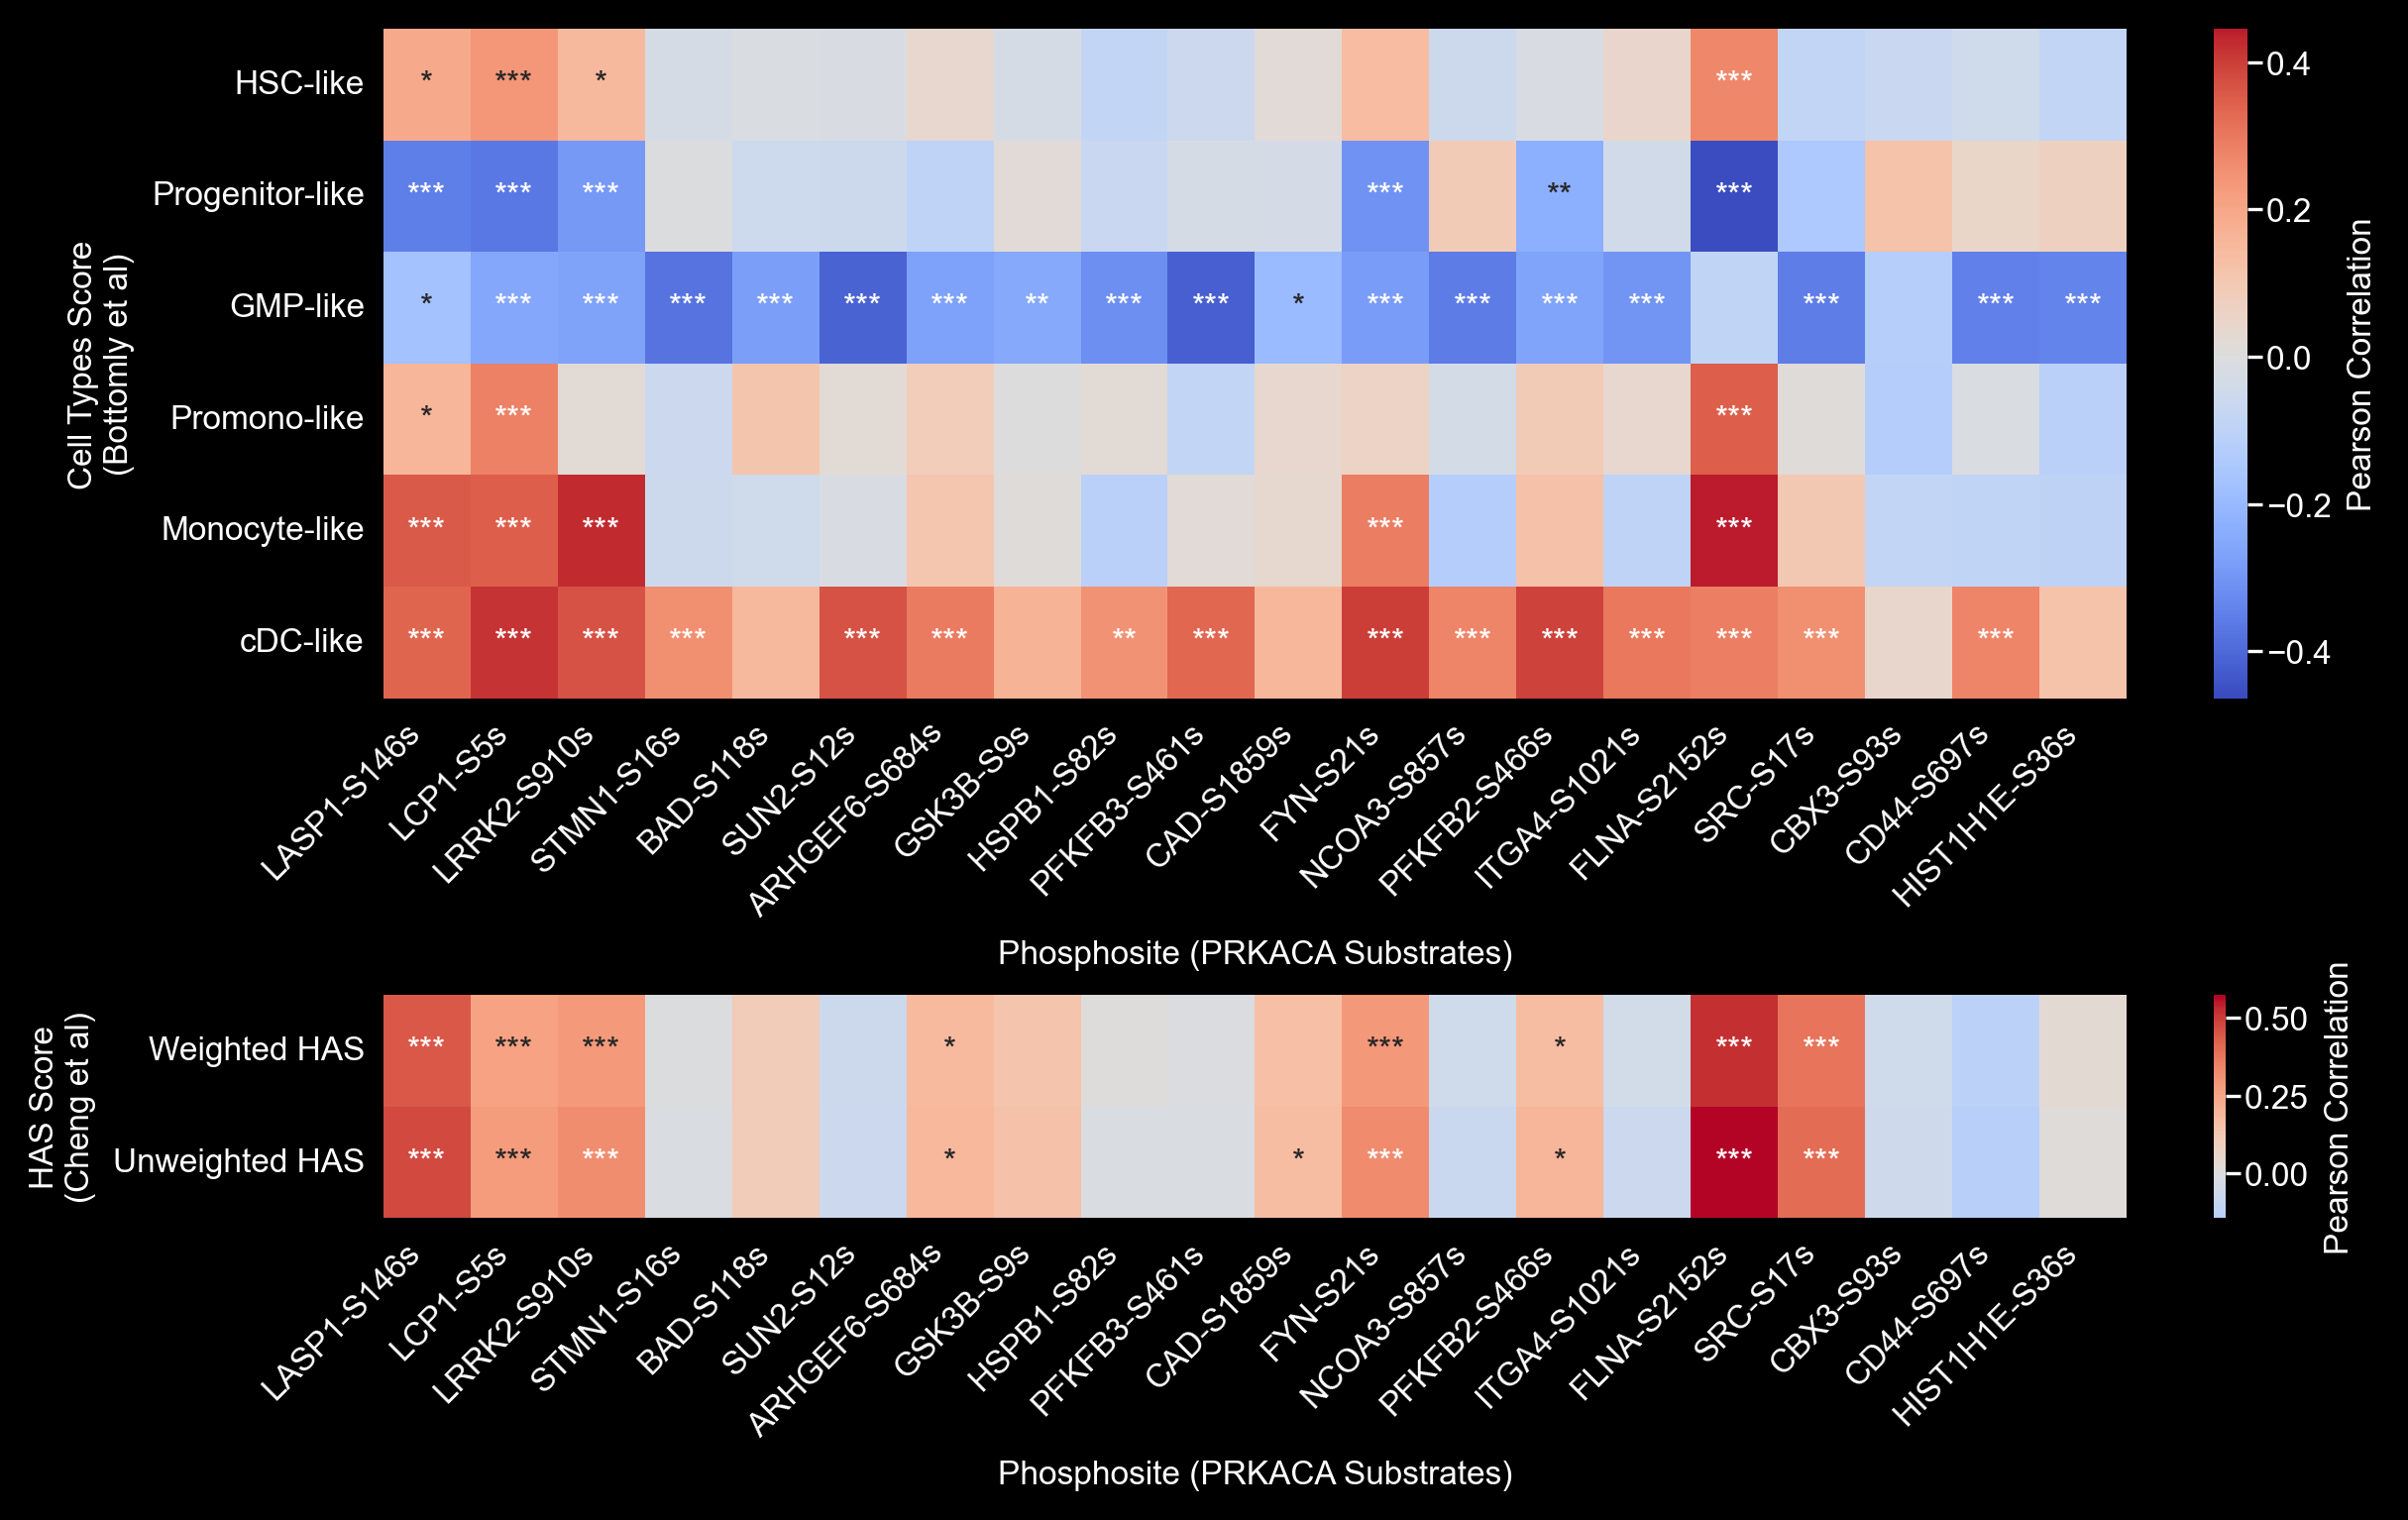

In [41]:
from figure2c import make_figure as make_figure_2c
fig_2c = make_figure_2c()